In [2]:
from a3em.datasets import arden
import os
from pathlib import Path

In [3]:
prefetch_path = Path(os.getenv('PREFETCH_PATH'))
X_train, X_test, y_train, y_test = arden.load_data(prefetch_path, random_state=123)

prefetching data...
local data found


In [4]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
108,23.437500,131.479134,109.114844,22.460938,124.023438,-239.949573,215.480924,12.683605,27.450771,9.969726,...,0.001534,0.000692,0.000419,0.000306,0.000179,0.000079,0.000032,0.000010,2.325721e-06,4.485630e-07
141,22.460938,113.318518,93.047050,22.460938,126.953125,-283.407941,219.353551,27.589489,26.634377,29.320037,...,0.000366,0.000182,0.000089,0.000051,0.000018,0.000008,0.000004,0.000001,4.849924e-07,1.305073e-07
19,55.664062,156.512551,134.379832,23.437500,165.039062,-294.283564,201.174292,-8.764452,23.626552,-2.545009,...,0.001232,0.000860,0.000504,0.000209,0.000108,0.000042,0.000019,0.000009,3.100925e-06,1.150773e-06
120,23.437500,106.667424,90.428045,22.460938,115.234375,-276.502642,220.106922,35.009477,27.049288,24.789322,...,0.000336,0.000187,0.000102,0.000062,0.000032,0.000014,0.000006,0.000003,1.585009e-06,1.249641e-06
48,41.015625,184.689889,142.453849,27.343750,300.781250,-190.161678,216.008476,-39.503599,38.500591,-29.422877,...,0.022118,0.011840,0.005529,0.004427,0.002883,0.000825,0.000210,0.000081,2.737891e-05,1.946964e-05


In [5]:
y_train.head()

108    1
141    1
19     0
120    1
48     0
Name: label, dtype: int64

In [6]:
X_train.to_csv('./data/train/features.csv')
X_test.to_csv('./data/test/features.csv')
y_train.to_csv('./data/train/labels.csv')
y_test.to_csv('./data/test/labels.csv')

## Analysis

In [7]:
import pandas as pd

In [8]:
train_features = pd.read_csv('./data/train/features.csv')
test_feature = pd.read_csv('./data/test/features.csv')
train_labels = pd.read_csv('./data/train/labels.csv')
test_labels = pd.read_csv('./data/test/labels.csv')

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [9]:
labels_aggregate['label'].value_counts()

label
1    184
0     59
Name: count, dtype: int64

In [10]:
# Combine
df = train_features.copy()
df['label'] = train_labels['label']

In [11]:
df.head()

,Unnamed: 0,peak_freq,centroid,bandwidth,freq_5,freq_95,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
0,108,23.437500,131.479134,109.114844,22.460938,124.023438,-239.949573,215.480924,12.683605,27.450771,...,0.000692,0.000419,0.000306,0.000179,0.000079,0.000032,0.000010,2.325721e-06,4.485630e-07,1
1,141,22.460938,113.318518,93.047050,22.460938,126.953125,-283.407941,219.353551,27.589489,26.634377,...,0.000182,0.000089,0.000051,0.000018,0.000008,0.000004,0.000001,4.849924e-07,1.305073e-07,1
2,19,55.664062,156.512551,134.379832,23.437500,165.039062,-294.283564,201.174292,-8.764452,23.626552,...,0.000860,0.000504,0.000209,0.000108,0.000042,0.000019,0.000009,3.100925e-06,1.150773e-06,0
3,120,23.437500,106.667424,90.428045,22.460938,115.234375,-276.502642,220.106922,35.009477,27.049288,...,0.000187,0.000102,0.000062,0.000032,0.000014,0.000006,0.000003,1.585009e-06,1.249641e-06,1
4,48,41.015625,184.689889,142.453849,27.343750,300.781250,-190.161678,216.008476,-39.503599,38.500591,...,0.011840,0.005529,0.004427,0.002883,0.000825,0.000210,0.000081,2.737891e-05,1.946964e-05,0


### Compute Summary Statistics

In [12]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
Unnamed: 0,31.488372,94.482014,16.755059,53.187303
peak_freq,36.428052,24.828575,12.338917,2.999569
centroid,166.003955,118.085019,28.576500,11.085297
bandwidth,134.060997,98.704904,17.321418,9.923240
freq_5,23.028706,23.669346,4.486485,2.081860
freq_95,241.687863,120.960263,64.882332,6.491851
mfcc_1,-205.301073,-266.369633,86.027552,32.017304
mfcc_2,213.789061,217.792723,14.909209,7.550003
mfcc_3,-20.913642,24.685065,25.438478,14.336169
mfcc_4,30.595288,22.722915,8.157653,5.641850


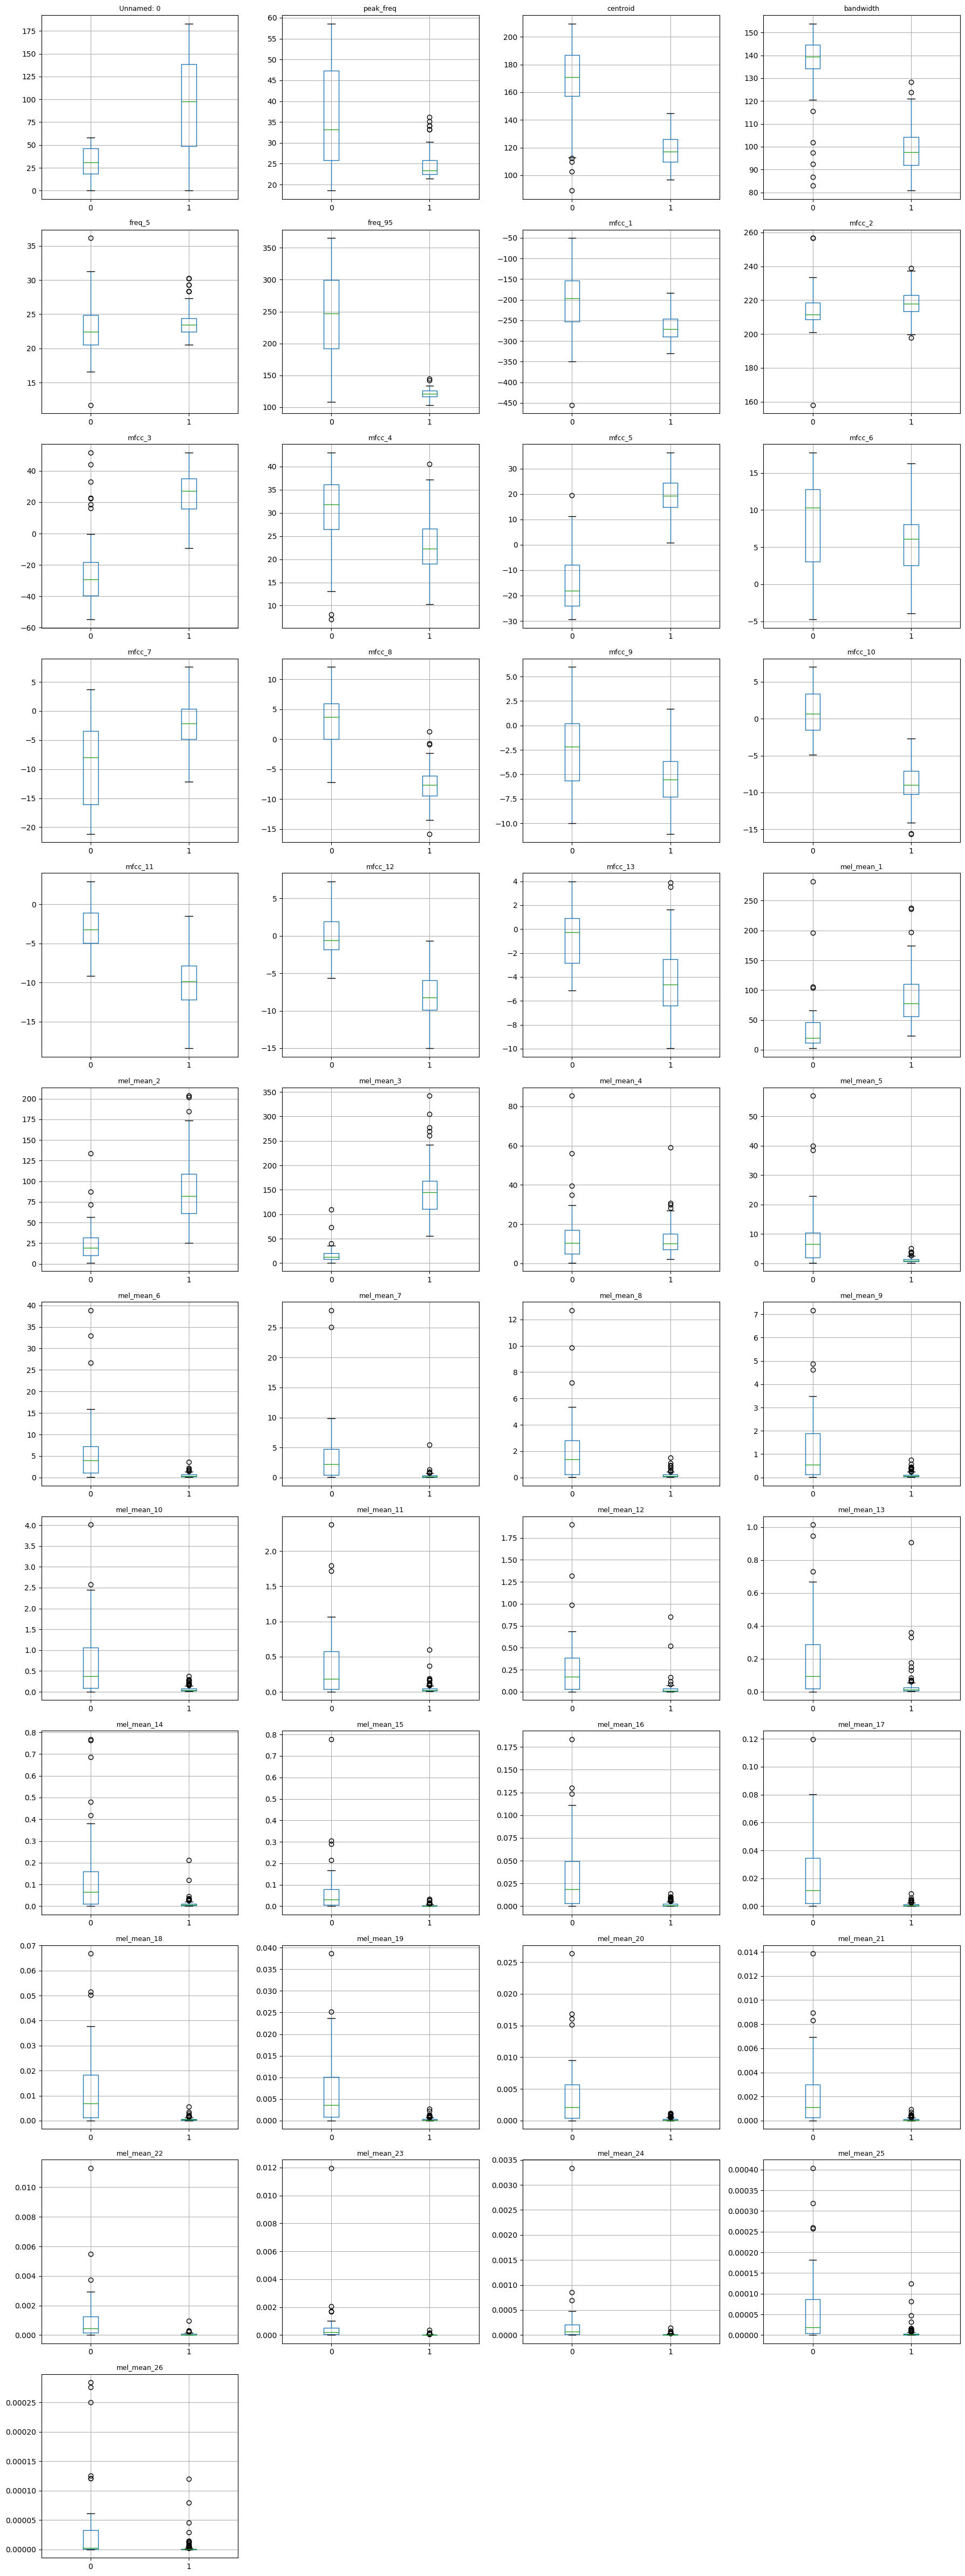

In [13]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [14]:
from scipy.stats import mannwhitneyu

In [15]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [16]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
15,mfcc_10,5969.0,5.587823e-23
21,mel_mean_3,41.0,1.651752e-22
13,mfcc_8,5856.0,2.176305e-21
5,freq_95,5831.5,4.477267e-21
17,mfcc_12,5813.0,8.455296e-21
10,mfcc_5,172.0,1.085987e-20
16,mfcc_11,5701.0,2.638923e-19
20,mel_mean_2,390.0,7.616238e-18
3,bandwidth,5488.0,1.259791e-16
8,mfcc_3,566.0,1.038037e-15


In [17]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
15,mfcc_10,5969.0,5.587823e-23,True
21,mel_mean_3,41.0,1.651752e-22,True
13,mfcc_8,5856.0,2.176305e-21,True
5,freq_95,5831.5,4.477267e-21,True
17,mfcc_12,5813.0,8.455296e-21,True
10,mfcc_5,172.0,1.085987e-20,True
16,mfcc_11,5701.0,2.638923e-19,True
20,mel_mean_2,390.0,7.616238e-18,True
3,bandwidth,5488.0,1.259791e-16,True
8,mfcc_3,566.0,1.038037e-15,True


In [18]:
results["Significant"].value_counts()

Significant
True     43
False     2
Name: count, dtype: int64

In [19]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant
4,freq_5,2544.5,0.137149,False
22,mel_mean_4,2882.0,0.725514,False


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [20]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [21]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(182, 44)
(61, 44)
label
1    139
0     43
Name: count, dtype: int64
label
1    45
0    16
Name: count, dtype: int64


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [24]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[16  0]
 [ 0 45]]


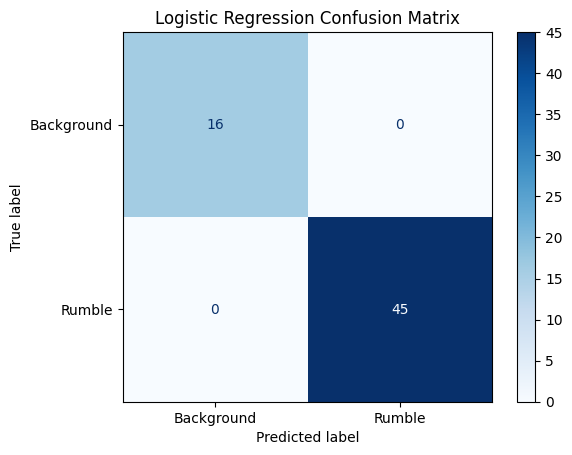

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        45

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



In [28]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 1.000


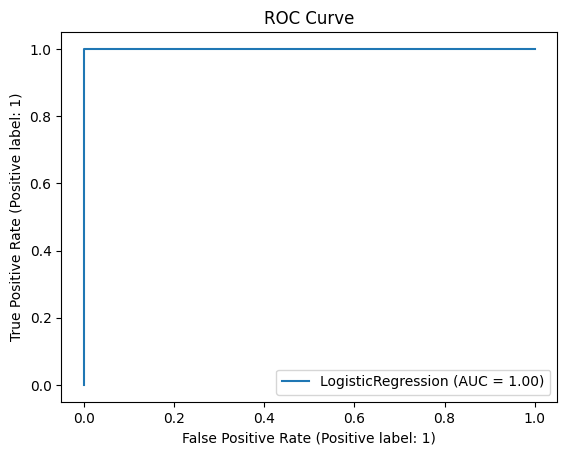

In [29]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [32]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
20,mel_mean_3,0.890447,0.890447
14,mfcc_10,-0.835848,0.835848
0,peak_freq,-0.826697,0.826697
13,mfcc_9,-0.816294,0.816294
15,mfcc_11,-0.611616,0.611616
4,freq_95,-0.532217,0.532217
12,mfcc_8,-0.522176,0.522176
16,mfcc_12,-0.480381,0.480381
5,mfcc_1,0.472845,0.472845
9,mfcc_5,0.384127,0.384127


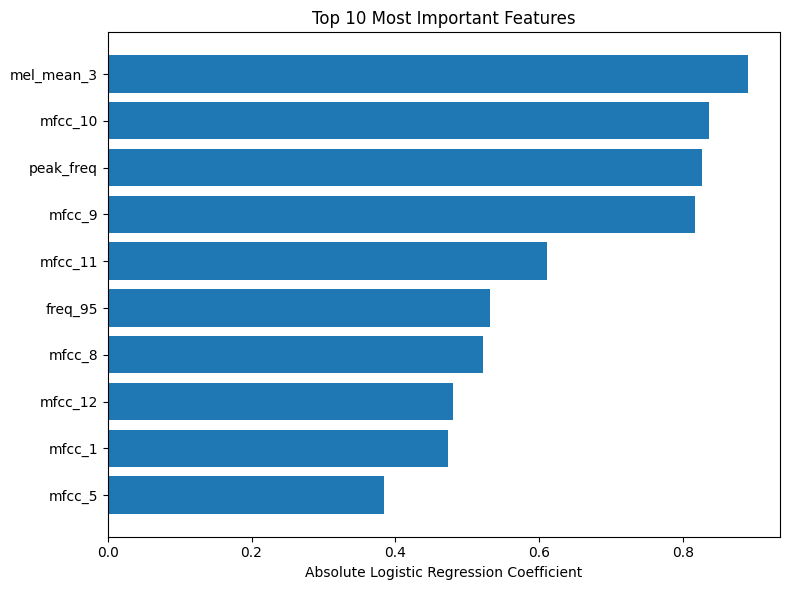

In [33]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [34]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,mel_mean_3,0.890447,0.890447,41.0,1.651752e-22,True,3.716441e-21,True
1,mfcc_10,-0.835848,0.835848,5969.0,5.587823e-23,True,2.514520e-21,True
2,peak_freq,-0.826697,0.826697,4922.0,1.090264e-10,True,1.635396e-10,True
3,mfcc_9,-0.816294,0.816294,4329.0,9.062229e-06,True,9.946349e-06,True
4,mfcc_11,-0.611616,0.611616,5701.0,2.638923e-19,True,1.696451e-18,True
5,freq_95,-0.532217,0.532217,5831.5,4.477267e-21,True,5.036925e-20,True
6,mfcc_8,-0.522176,0.522176,5856.0,2.176305e-21,True,3.264457e-20,True
7,mfcc_12,-0.480381,0.480381,5813.0,8.455296e-21,True,7.609767e-20,True
8,mfcc_1,0.472845,0.472845,4540.0,2.787082e-07,True,3.215864e-07,True
9,mfcc_5,0.384127,0.384127,172.0,1.085987e-20,True,8.144903e-20,True


### Cross Validation with Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [37]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [38]:
rf_pred = rf_model.predict(X_test)

In [39]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.98      0.99        45

    accuracy                           0.98        61
   macro avg       0.97      0.99      0.98        61
weighted avg       0.98      0.98      0.98        61



### RandomForest Feature Importance

In [40]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
14,mfcc_10,0.168090
20,mel_mean_3,0.133767
4,freq_95,0.120566
9,mfcc_5,0.084299
1,centroid,0.079137
12,mfcc_8,0.076209
2,bandwidth,0.051818
7,mfcc_3,0.046976
16,mfcc_12,0.024234
15,mfcc_11,0.024148


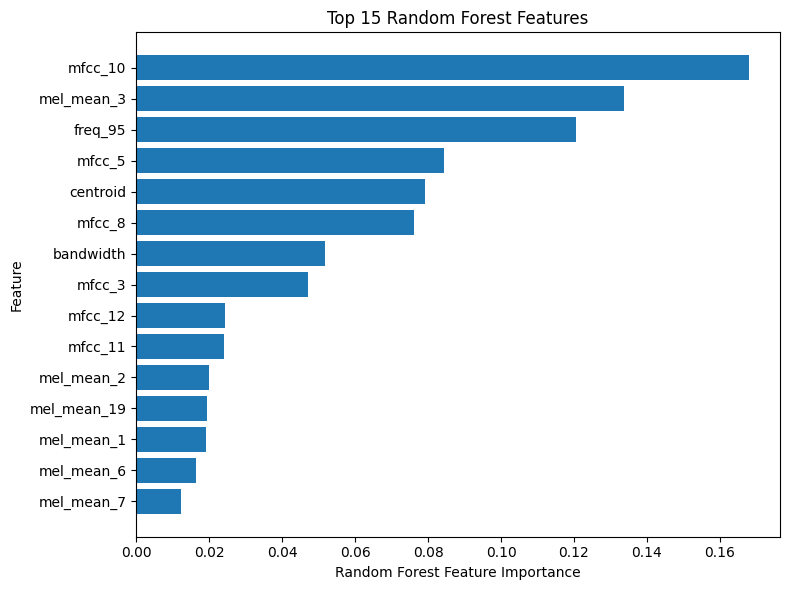

In [41]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [42]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
0,mfcc_10,5.587823e-23,-0.835848,0.168090,1,2,1,1.333333
1,mel_mean_3,1.651752e-22,0.890447,0.133767,2,1,2,1.666667
3,freq_95,4.477267e-21,-0.532217,0.120566,4,6,3,4.333333
2,mfcc_8,2.176305e-21,-0.522176,0.076209,3,7,6,5.333333
5,mfcc_5,1.085987e-20,0.384127,0.084299,6,10,4,6.666667
4,mfcc_12,8.455296e-21,-0.480381,0.024234,5,8,9,7.333333
6,mfcc_11,2.638923e-19,-0.611616,0.024148,7,5,10,7.333333
8,bandwidth,1.259791e-16,-0.208165,0.051818,9,14,7,10.000000
7,mel_mean_2,7.616238e-18,0.288818,0.019992,8,12,11,10.333333
10,centroid,1.472650e-15,-0.151708,0.079137,11,18,5,11.333333
